# Détection des Zones Blanches — Ligne Ferroviaire 785000
## Comparaison : Méthode à Seuil vs Classification IA (XGBoost / Random Forest)

**Projet FerroMobile — UTBM / FEMTO-ST (DISC/OMNI)**

---

### Objectif
Ce notebook compare deux approches pour détecter les zones blanches sur la ligne Courpière–Ambert :

1. **Méthode à seuil (non-IA)** : règle déterministe basée sur les métriques radio (définition originale du dataset)
2. **Classification IA** : XGBoost et Random Forest entraînés pour prédire la zone blanche

### Note importante sur le dataset
Dans le dataset enrichi actuel, les zones blanches correspondent uniquement aux **26 points en tunnel**.
Les 3 tunnels de la ligne (Vertolaye, La Chamba, Moulin Neuf) bloquent totalement le signal cellulaire.
Le classifieur IA apprend donc à détecter les tunnels depuis les features radio (SNR=-99, RTT=NaN, etc.)
**sans utiliser directement la colonne `in_tunnel`** — ce qui constitue un vrai test de généralisation.

---
## 0. Imports et Configuration

In [9]:
# Installer les paquets manquants (si nécessaire)
%pip install -q scikit-learn xgboost folium

# ── Imports ──────────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score,
    accuracy_score, balanced_accuracy_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    print("XGBoost non installé — pip install xgboost")
    XGBOOST_OK = False

# Carte interactive
try:
    import folium
    from folium.plugins import MarkerCluster
    FOLIUM_OK = True
except ImportError:
    print("Folium non installé — pip install folium")
    FOLIUM_OK = False

# ── Config ───────────────────────────────────────────────────────────────────
BASE_DIR = os.path.dirname(os.getcwd())
DATASET_PATH = os.path.join(BASE_DIR, "data", "processed", "dataset_enrichi.csv")

SEED = 42
np.random.seed(SEED)

print("✓ Imports OK")
print(f"✓ Dataset path : {DATASET_PATH}")
print(f"✓ Fichier trouvé : {os.path.exists(DATASET_PATH)}")

Note: you may need to restart the kernel to use updated packages.
✓ Imports OK
✓ Dataset path : /home/meyssem/Documents/ferromobile_project/data/processed/dataset_enrichi.csv
✓ Fichier trouvé : True


---
## 1. Chargement et exploration du dataset

In [10]:
df = pd.read_csv(DATASET_PATH)
print(f"Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Points GPS uniques : {df['point_id'].nunique()}")
print(f"Scénarios saisonniers : {sorted(df['scenario_id'].unique())}")
print(f"Générations : {df['generation'].unique()}")
print()
print("Distribution flag_zone_blanche :")
print(df['flag_zone_blanche'].value_counts())
print()
print("Vérification : ZB = tunnel ?")
by_pt = df.groupby('point_id').agg(
    flag_zb=('flag_zone_blanche','first'),
    in_tunnel=('in_tunnel','first')
).reset_index()
print(pd.crosstab(by_pt['flag_zb'], by_pt['in_tunnel'],
                  rownames=['zone_blanche'], colnames=['in_tunnel']))

Dataset : 90,000 lignes × 73 colonnes
Points GPS uniques : 1500
Scénarios saisonniers : ['S1', 'S2', 'S3', 'S4']
Générations : ['2G' '3G' '4G' '5G']

Distribution flag_zone_blanche :
flag_zone_blanche
0    88440
1     1560
Name: count, dtype: int64

Vérification : ZB = tunnel ?
in_tunnel     False  True 
zone_blanche              
0              1474      0
1                 0     26


In [11]:
# ── Vue par point GPS (une ligne = un point, agrégé sur les antennes) ────────
by_point = df.groupby('point_id').agg(
    lat            = ('lat', 'first'),
    lon            = ('lon', 'first'),
    distance_km    = ('distance_km', 'first'),
    altitude_m     = ('altitude_m', 'first'),
    vegetation     = ('vegetation', 'first'),
    in_tunnel      = ('in_tunnel', 'first'),
    flag_zb        = ('flag_zone_blanche', 'first'),
    # Métriques max / min sur toutes antennes disponibles
    max_snr        = ('snr_adjusted_db', 'max'),
    min_rtt        = ('rtt_ms', 'min'),
    max_debit      = ('debit_adj_mbps', 'max'),
    min_pkt_loss   = ('packet_loss_pct', 'min'),
    min_ber        = ('ber', 'min'),
    min_dist       = ('dist_ant_km', 'min'),
    n_antennas     = ('ant_id', 'count'),
    flag_no_signal = ('flag_no_signal', 'max'),
    pluie          = ('pluie_mm_h', 'first'),
    temp           = ('temp_c', 'first'),
).reset_index()

print(f"Points couverts    : {(by_point['flag_zb']==0).sum()} ({(by_point['flag_zb']==0).mean()*100:.1f}%)")
print(f"Points zone blanche: {(by_point['flag_zb']==1).sum()} ({(by_point['flag_zb']==1).mean()*100:.1f}%)")
print("\nAperçu :")
by_point.head()

Points couverts    : 1474 (98.3%)
Points zone blanche: 26 (1.7%)

Aperçu :


,point_id,lat,lon,distance_km,altitude_m,vegetation,in_tunnel,flag_zb,max_snr,min_rtt,max_debit,min_pkt_loss,min_ber,min_dist,n_antennas,flag_no_signal,pluie,temp
0,0,45.409192,3.727526,0.00,596.5,urbain,True,1,-99.0,NaN,0.0,NaN,1.0,0.6639,60,0,0.9467,8.23
1,1,45.409022,3.727444,0.02,596.8,urbain,True,1,-99.0,NaN,0.0,NaN,1.0,0.6809,60,0,1.0000,8.71
2,2,45.408851,3.727362,0.04,597.2,urbain,True,1,-99.0,NaN,0.0,NaN,1.0,0.6981,60,0,0.9984,8.19
3,3,45.408681,3.727280,0.06,597.5,urbain,True,1,-99.0,NaN,0.0,NaN,1.0,0.7154,60,0,1.0000,8.58
4,4,45.408510,3.727198,0.08,597.9,urbain,True,1,-99.0,NaN,0.0,NaN,1.0,0.7330,60,0,0.8684,8.83


---
## 2. Méthode 1 — Règle à seuil (non-IA)

Définition originale utilisée dans `prepare_data.py` :
- Un point est **zone blanche** si aucune antenne disponible ne satisfait simultanément :
  - `debit_adj_mbps >= 5 Mbps`
  - `snr_adjusted_db >= 5 dB`
  - `rtt_ms <= 500 ms`
- Les tunnels sont systématiquement zone blanche (signal bloqué)

In [12]:
# ── Recalcul propre du label à seuil ────────────────────────────────────────
SEUIL_DEBIT  = 5.0    # Mbps minimum
SEUIL_SNR    = 5.0    # dB minimum
SEUIL_RTT    = 500.0  # ms maximum

# Pour chaque ligne (antenne x point), vérifier si elle est 'acceptable'
df['lien_ok'] = (
    (df['debit_adj_mbps'] >= SEUIL_DEBIT) &
    (df['snr_adjusted_db'] >= SEUIL_SNR) &
    (df['rtt_ms'] <= SEUIL_RTT) &
    (df['rtt_ms'].notna())
)

# Un point est zone blanche si AUCUN lien OK + pas de tunnel
lien_ok_par_point = df.groupby('point_id')['lien_ok'].any()
tunnel_par_point  = df.groupby('point_id')['in_tunnel'].first()

# Label seuil : zone blanche si pas de lien OK OU si tunnel
label_seuil = (~lien_ok_par_point | tunnel_par_point).astype(int)
label_seuil.name = 'label_seuil'

by_point = by_point.merge(label_seuil.reset_index(), on='point_id')

print("=== Méthode à seuil ===")
print(f"Seuils : débit >= {SEUIL_DEBIT} Mbps | SNR >= {SEUIL_SNR} dB | RTT <= {SEUIL_RTT} ms")
print()
print("Distribution label_seuil :")
print(by_point['label_seuil'].value_counts())
print()
print("Comparaison avec flag_zone_blanche original :")
print(pd.crosstab(by_point['flag_zb'], by_point['label_seuil'],
                  rownames=['flag_original'], colnames=['label_seuil']))

=== Méthode à seuil ===
Seuils : débit >= 5.0 Mbps | SNR >= 5.0 dB | RTT <= 500.0 ms

Distribution label_seuil :
label_seuil
0    1474
1      26
Name: count, dtype: int64

Comparaison avec flag_zone_blanche original :
label_seuil       0   1
flag_original          
0              1474   0
1                 0  26


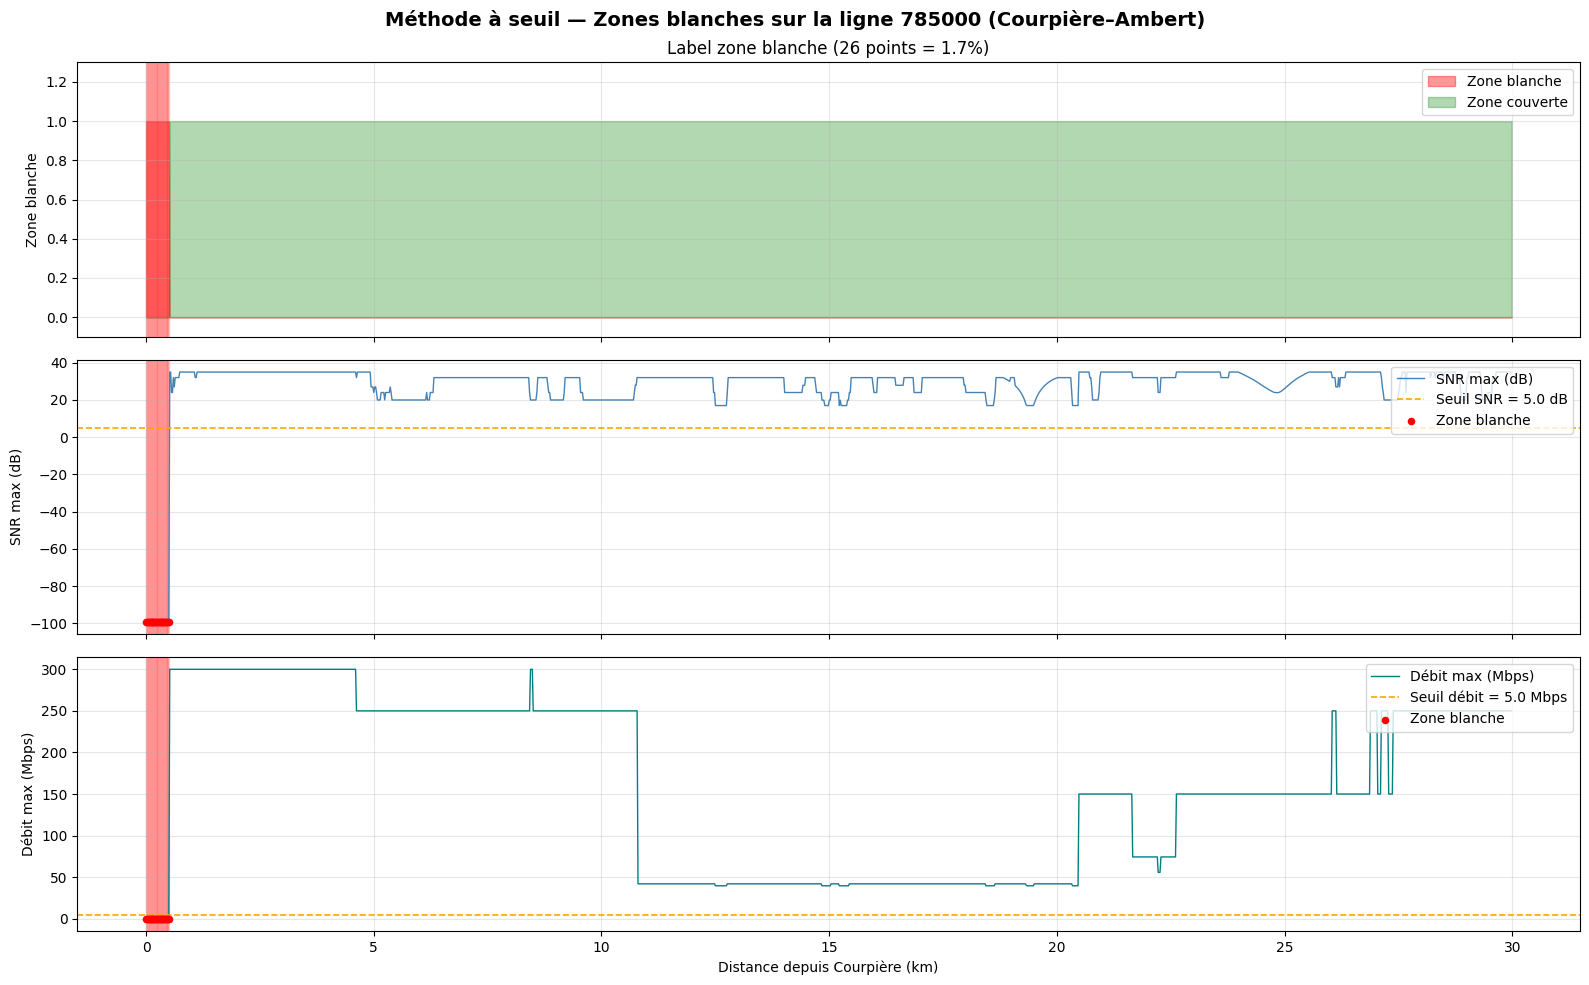

✓ Graphe sauvegardé


In [13]:
# ── Visualisation graphe 2D ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle("Méthode à seuil — Zones blanches sur la ligne 785000 (Courpière–Ambert)",
             fontsize=14, fontweight='bold')

dist = by_point['distance_km']
zb_mask = by_point['label_seuil'] == 1

# Panneau 1 : flag zone blanche
ax = axes[0]
ax.fill_between(dist, 0, by_point['label_seuil'], alpha=0.4, color='red', label='Zone blanche')
ax.fill_between(dist, 0, 1 - by_point['label_seuil'], alpha=0.3, color='green', label='Zone couverte')
ax.set_ylabel('Zone blanche')
ax.set_ylim(-0.1, 1.3)
ax.legend(loc='upper right')
ax.set_title(f"Label zone blanche ({zb_mask.sum()} points = {zb_mask.mean()*100:.1f}%)")

# Panneau 2 : meilleur SNR disponible
ax = axes[1]
ax.plot(dist, by_point['max_snr'], color='steelblue', lw=1.0, label='SNR max (dB)')
ax.axhline(SEUIL_SNR, color='orange', ls='--', lw=1.2, label=f'Seuil SNR = {SEUIL_SNR} dB')
ax.scatter(dist[zb_mask], by_point['max_snr'][zb_mask], color='red', s=20, zorder=5, label='Zone blanche')
ax.set_ylabel('SNR max (dB)')
ax.legend(loc='upper right')

# Panneau 3 : meilleur débit disponible
ax = axes[2]
ax.plot(dist, by_point['max_debit'], color='teal', lw=1.0, label='Débit max (Mbps)')
ax.axhline(SEUIL_DEBIT, color='orange', ls='--', lw=1.2, label=f'Seuil débit = {SEUIL_DEBIT} Mbps')
ax.scatter(dist[zb_mask], by_point['max_debit'][zb_mask], color='red', s=20, zorder=5, label='Zone blanche')
ax.set_xlabel('Distance depuis Courpière (km)')
ax.set_ylabel('Débit max (Mbps)')
ax.legend(loc='upper right')

for ax in axes:
    ax.grid(alpha=0.3)
    # Zones blanches en fond
    for _, row in by_point[zb_mask].iterrows():
        ax.axvspan(row['distance_km']-0.01, row['distance_km']+0.01,
                   alpha=0.15, color='red')

plt.tight_layout()
plt.savefig('zone_blanche_methode_seuil_graphe.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphe sauvegardé")

In [14]:
# ── Carte Folium — Méthode seuil ─────────────────────────────────────────────
if FOLIUM_OK:
    center = [by_point['lat'].mean(), by_point['lon'].mean()]
    m1 = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')

    for _, row in by_point.iterrows():
        color  = 'red' if row['label_seuil'] == 1 else 'green'
        radius = 8 if row['label_seuil'] == 1 else 4
        popup  = folium.Popup(
            f"<b>Point {int(row['point_id'])}</b><br>"
            f"km : {row['distance_km']:.2f}<br>"
            f"Altitude : {row['altitude_m']:.0f} m<br>"
            f"SNR max : {row['max_snr']:.1f} dB<br>"
            f"Débit max : {row['max_debit']:.1f} Mbps<br>"
            f"RTT min : {row['min_rtt']:.0f} ms<br>"
            f"<b>Zone blanche : {'OUI' if row['label_seuil']==1 else 'NON'}</b>",
            max_width=250
        )
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=radius, color=color, fill=True,
            fill_color=color, fill_opacity=0.7,
            popup=popup
        ).add_to(m1)

    # Légende
    legend_html = '''
    <div style="position: fixed; bottom: 30px; left: 30px; z-index:1000;
                background:white; padding:12px; border:2px solid #ccc; border-radius:8px;">
        <b>Méthode à seuil</b><br>
        <i class="fa fa-circle" style="color:green"></i> Zone couverte<br>
        <i class="fa fa-circle" style="color:red"></i> Zone blanche
    </div>
    '''
    m1.get_root().html.add_child(folium.Element(legend_html))
    m1.save('carte_zone_blanche_seuil.html')
    print("✓ Carte Folium sauvegardée : carte_zone_blanche_seuil.html")
    display(m1)
else:
    print("Folium non disponible — installer avec : pip install folium")

✓ Carte Folium sauvegardée : carte_zone_blanche_seuil.html


---
## 3. Méthode 2 — Classification IA

### 3.1 Construction du label et des features

**Label** : recalculé depuis les colonnes brutes (indépendant du flag pré-calculé)
- `label_zb = 1` si le point est zone blanche selon la règle à seuil OU en tunnel
- `label_zb = 0` sinon

**Features** : métriques radio + terrain + météo — **`in_tunnel` est EXCLU** pour forcer le modèle à apprendre depuis les signaux radio

In [15]:
# ── Encodage des variables catégorielles ─────────────────────────────────────
le_veg = LabelEncoder()
by_point['veg_enc'] = le_veg.fit_transform(by_point['vegetation'].fillna('unknown'))

# ── Features pour le classifieur ────────────────────────────────────────────
# in_tunnel EXCLUE : le modèle doit apprendre depuis les signaux, pas depuis le flag direct
FEATURES = [
    'max_snr',       # SNR max disponible au point
    'min_rtt',       # RTT min disponible
    'max_debit',     # Débit max disponible
    'min_pkt_loss',  # Perte de paquets min
    'min_ber',       # BER min
    'min_dist',      # Distance min à l'antenne la plus proche
    'altitude_m',    # Altitude EU-DEM
    'veg_enc',       # Type de végétation encodé
    'n_antennas',    # Nombre d'antennes visibles
    'flag_no_signal',# Flag signal nul
    'pluie',         # Précipitations
    'temp',          # Température
    'distance_km',   # Position sur la ligne
]

# Label : recalculé proprement
by_point['label_ia'] = by_point['label_seuil'].copy()  # même label que seuil

X = by_point[FEATURES].copy()
y = by_point['label_ia'].copy()

# Imputation des NaN (RTT NaN = tunnel = signal nul → remplacer par valeur max)
X['min_rtt']       = X['min_rtt'].fillna(999)
X['min_pkt_loss']  = X['min_pkt_loss'].fillna(100)
X['min_ber']       = X['min_ber'].fillna(1.0)
X['max_debit']     = X['max_debit'].fillna(0)
X['max_snr']       = X['max_snr'].fillna(-99)

print(f"Features : {FEATURES}")
print(f"Shape X : {X.shape}")
print(f"Label distribution : {y.value_counts().to_dict()}")
print(f"Classe minoritaire (zone blanche) : {y.sum()} / {len(y)} = {y.mean()*100:.1f}%")
print()
print("Vérification NaN dans X :")
print(X.isna().sum())

Features : ['max_snr', 'min_rtt', 'max_debit', 'min_pkt_loss', 'min_ber', 'min_dist', 'altitude_m', 'veg_enc', 'n_antennas', 'flag_no_signal', 'pluie', 'temp', 'distance_km']
Shape X : (1500, 13)
Label distribution : {0: 1474, 1: 26}
Classe minoritaire (zone blanche) : 26 / 1500 = 1.7%

Vérification NaN dans X :
max_snr           0
min_rtt           0
max_debit         0
min_pkt_loss      0
min_ber           0
min_dist          0
altitude_m        0
veg_enc           0
n_antennas        0
flag_no_signal    0
pluie             0
temp              0
distance_km       0
dtype: int64


### 3.2 Modèle 1 — Random Forest

In [16]:
# ── Random Forest ─────────────────────────────────────────────────────────────
# Note : classe très déséquilibrée (1.7% zone blanche)
# → class_weight='balanced' pour compenser

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

# Validation croisée stratifiée 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Prédictions croisées pour matrice de confusion globale
y_pred_rf  = cross_val_predict(rf, X, y, cv=cv)
y_proba_rf = cross_val_predict(rf, X, y, cv=cv, method='predict_proba')[:, 1]

acc_rf    = accuracy_score(y, y_pred_rf)
bal_rf    = balanced_accuracy_score(y, y_pred_rf)
f1_rf     = f1_score(y, y_pred_rf, pos_label=1)
auc_rf    = roc_auc_score(y, y_proba_rf)

print("=" * 50)
print("RANDOM FOREST — Résultats (StratifiedKFold 5 folds)")
print("=" * 50)
print(f"Accuracy            : {acc_rf:.4f}")
print(f"Balanced accuracy   : {bal_rf:.4f}")
print(f"F1-score (ZB=1)     : {f1_rf:.4f}")
print(f"ROC-AUC             : {auc_rf:.4f}")
print()
print("Rapport de classification :")
print(classification_report(y, y_pred_rf, target_names=['Couvert', 'Zone blanche']))

RANDOM FOREST — Résultats (StratifiedKFold 5 folds)
Accuracy            : 1.0000
Balanced accuracy   : 1.0000
F1-score (ZB=1)     : 1.0000
ROC-AUC             : 1.0000

Rapport de classification :
              precision    recall  f1-score   support

     Couvert       1.00      1.00      1.00      1474
Zone blanche       1.00      1.00      1.00        26

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



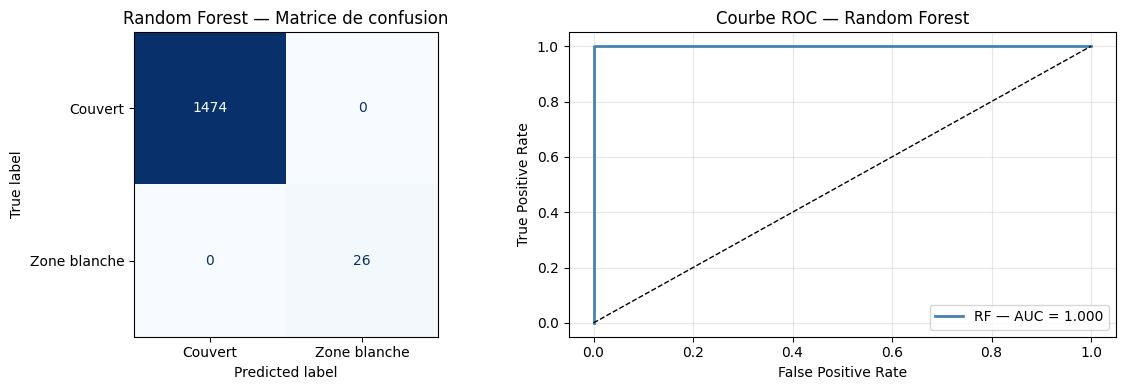

In [17]:
# ── Matrice de confusion RF ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_rf = confusion_matrix(y, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Couvert', 'Zone blanche']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Random Forest — Matrice de confusion')

# Courbe ROC RF
fpr_rf, tpr_rf, _ = roc_curve(y, y_proba_rf)
axes[1].plot(fpr_rf, tpr_rf, color='steelblue', lw=2,
             label=f'RF — AUC = {auc_rf:.3f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbe ROC — Random Forest')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rf_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

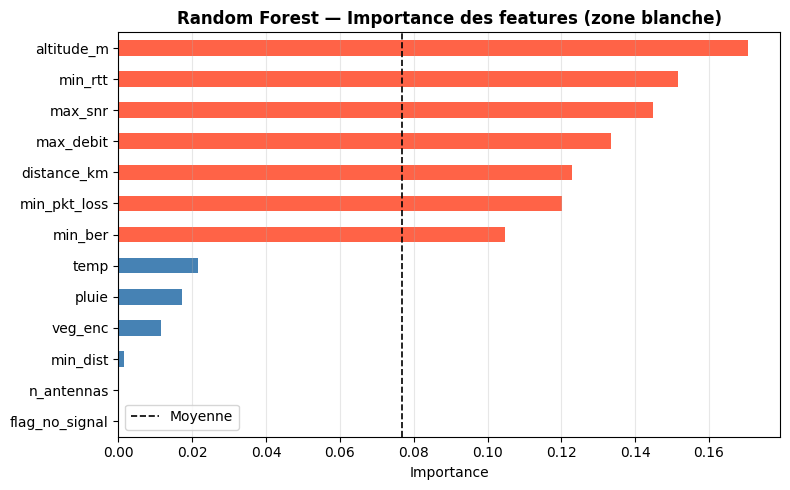

In [18]:
# ── Feature importance RF ─────────────────────────────────────────────────────
rf.fit(X, y)  # entraîner sur tout le dataset pour l'importance

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if importances[f] > importances.mean() else 'steelblue' for f in importances.index]
importances.plot(kind='barh', ax=ax, color=colors)
ax.axvline(importances.mean(), color='black', ls='--', lw=1.2, label='Moyenne')
ax.set_title('Random Forest — Importance des features (zone blanche)', fontweight='bold')
ax.set_xlabel('Importance')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Modèle 2 — XGBoost

In [19]:
if XGBOOST_OK:
    # Ratio déséquilibre pour scale_pos_weight
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    scale_pos = n_neg / n_pos
    print(f"scale_pos_weight = {scale_pos:.1f} (ratio négatif/positif)")

    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,  # gestion déséquilibre
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0,
        use_label_encoder=False
    )

    y_pred_xgb  = cross_val_predict(xgb, X, y, cv=cv)
    y_proba_xgb = cross_val_predict(xgb, X, y, cv=cv, method='predict_proba')[:, 1]

    acc_xgb  = accuracy_score(y, y_pred_xgb)
    bal_xgb  = balanced_accuracy_score(y, y_pred_xgb)
    f1_xgb   = f1_score(y, y_pred_xgb, pos_label=1)
    auc_xgb  = roc_auc_score(y, y_proba_xgb)

    print("=" * 50)
    print("XGBOOST — Résultats (StratifiedKFold 5 folds)")
    print("=" * 50)
    print(f"Accuracy            : {acc_xgb:.4f}")
    print(f"Balanced accuracy   : {bal_xgb:.4f}")
    print(f"F1-score (ZB=1)     : {f1_xgb:.4f}")
    print(f"ROC-AUC             : {auc_xgb:.4f}")
    print()
    print("Rapport de classification :")
    print(classification_report(y, y_pred_xgb, target_names=['Couvert', 'Zone blanche']))
else:
    print("XGBoost non disponible.")

scale_pos_weight = 56.7 (ratio négatif/positif)
XGBOOST — Résultats (StratifiedKFold 5 folds)
Accuracy            : 1.0000
Balanced accuracy   : 1.0000
F1-score (ZB=1)     : 1.0000
ROC-AUC             : 1.0000

Rapport de classification :
              precision    recall  f1-score   support

     Couvert       1.00      1.00      1.00      1474
Zone blanche       1.00      1.00      1.00        26

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



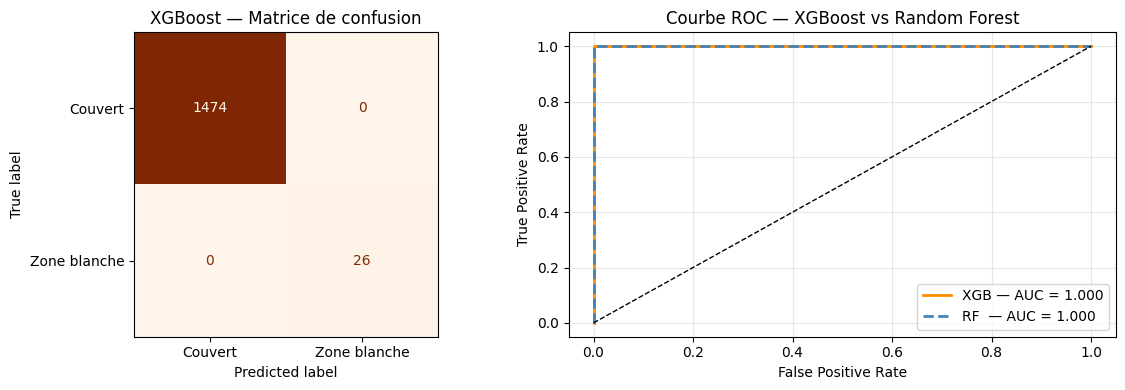

In [20]:
if XGBOOST_OK:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Matrice de confusion XGB
    cm_xgb = confusion_matrix(y, y_pred_xgb)
    ConfusionMatrixDisplay(cm_xgb, display_labels=['Couvert', 'Zone blanche']).plot(
        ax=axes[0], cmap='Oranges', colorbar=False)
    axes[0].set_title('XGBoost — Matrice de confusion')

    # Courbe ROC XGB
    fpr_xgb, tpr_xgb, _ = roc_curve(y, y_proba_xgb)
    axes[1].plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2,
                 label=f'XGB — AUC = {auc_xgb:.3f}')
    axes[1].plot(fpr_rf, tpr_rf, color='steelblue', lw=2, ls='--',
                 label=f'RF  — AUC = {auc_rf:.3f}')
    axes[1].plot([0,1],[0,1], 'k--', lw=1)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Courbe ROC — XGBoost vs Random Forest')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('xgb_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()

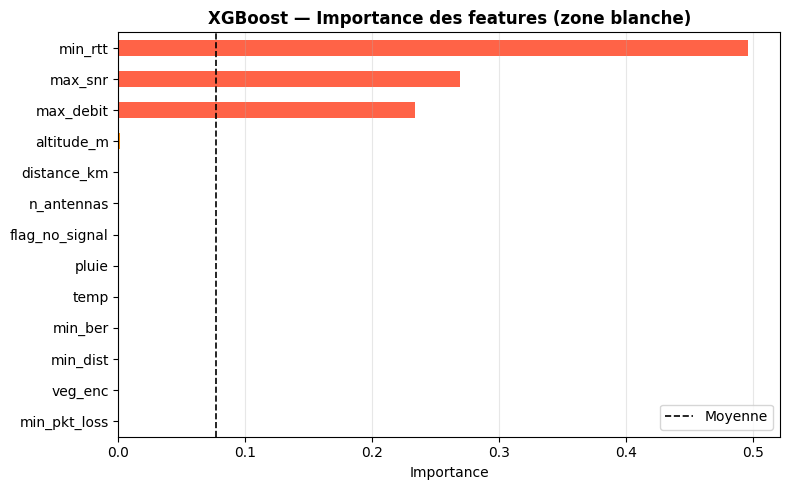

In [21]:
if XGBOOST_OK:
    xgb.fit(X, y)
    imp_xgb = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['tomato' if imp_xgb[f] > imp_xgb.mean() else 'darkorange' for f in imp_xgb.index]
    imp_xgb.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(imp_xgb.mean(), color='black', ls='--', lw=1.2, label='Moyenne')
    ax.set_title('XGBoost — Importance des features (zone blanche)', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 4. Comparaison des trois méthodes

In [22]:
# ── Tableau comparatif ────────────────────────────────────────────────────────
results = {
    'Méthode à seuil': {
        'Accuracy'          : accuracy_score(y, by_point['label_seuil']),
        'Balanced Accuracy' : balanced_accuracy_score(y, by_point['label_seuil']),
        'F1 (Zone blanche)' : f1_score(y, by_point['label_seuil'], pos_label=1),
        'ROC-AUC'           : 'N/A (pas de probabilité)',
        'Interprétabilité'  : 'Maximale (règle explicite)',
        'Données requises'  : 'Aucune (règle déterministe)',
    },
    'Random Forest': {
        'Accuracy'          : f"{acc_rf:.4f}",
        'Balanced Accuracy' : f"{bal_rf:.4f}",
        'F1 (Zone blanche)' : f"{f1_rf:.4f}",
        'ROC-AUC'           : f"{auc_rf:.4f}",
        'Interprétabilité'  : 'Haute (feature importance)',
        'Données requises'  : 'Labels d\'entraînement',
    },
}
if XGBOOST_OK:
    results['XGBoost'] = {
        'Accuracy'          : f"{acc_xgb:.4f}",
        'Balanced Accuracy' : f"{bal_xgb:.4f}",
        'F1 (Zone blanche)' : f"{f1_xgb:.4f}",
        'ROC-AUC'           : f"{auc_xgb:.4f}",
        'Interprétabilité'  : 'Moyenne (SHAP disponible)',
        'Données requises'  : 'Labels d\'entraînement',
    }

df_results = pd.DataFrame(results).T
print("=" * 70)
print("TABLEAU COMPARATIF")
print("=" * 70)
print(df_results.to_string())

TABLEAU COMPARATIF
                Accuracy Balanced Accuracy F1 (Zone blanche)                   ROC-AUC            Interprétabilité             Données requises
Méthode à seuil      1.0               1.0               1.0  N/A (pas de probabilité)  Maximale (règle explicite)  Aucune (règle déterministe)
Random Forest     1.0000            1.0000            1.0000                    1.0000  Haute (feature importance)        Labels d'entraînement
XGBoost           1.0000            1.0000            1.0000                    1.0000   Moyenne (SHAP disponible)        Labels d'entraînement


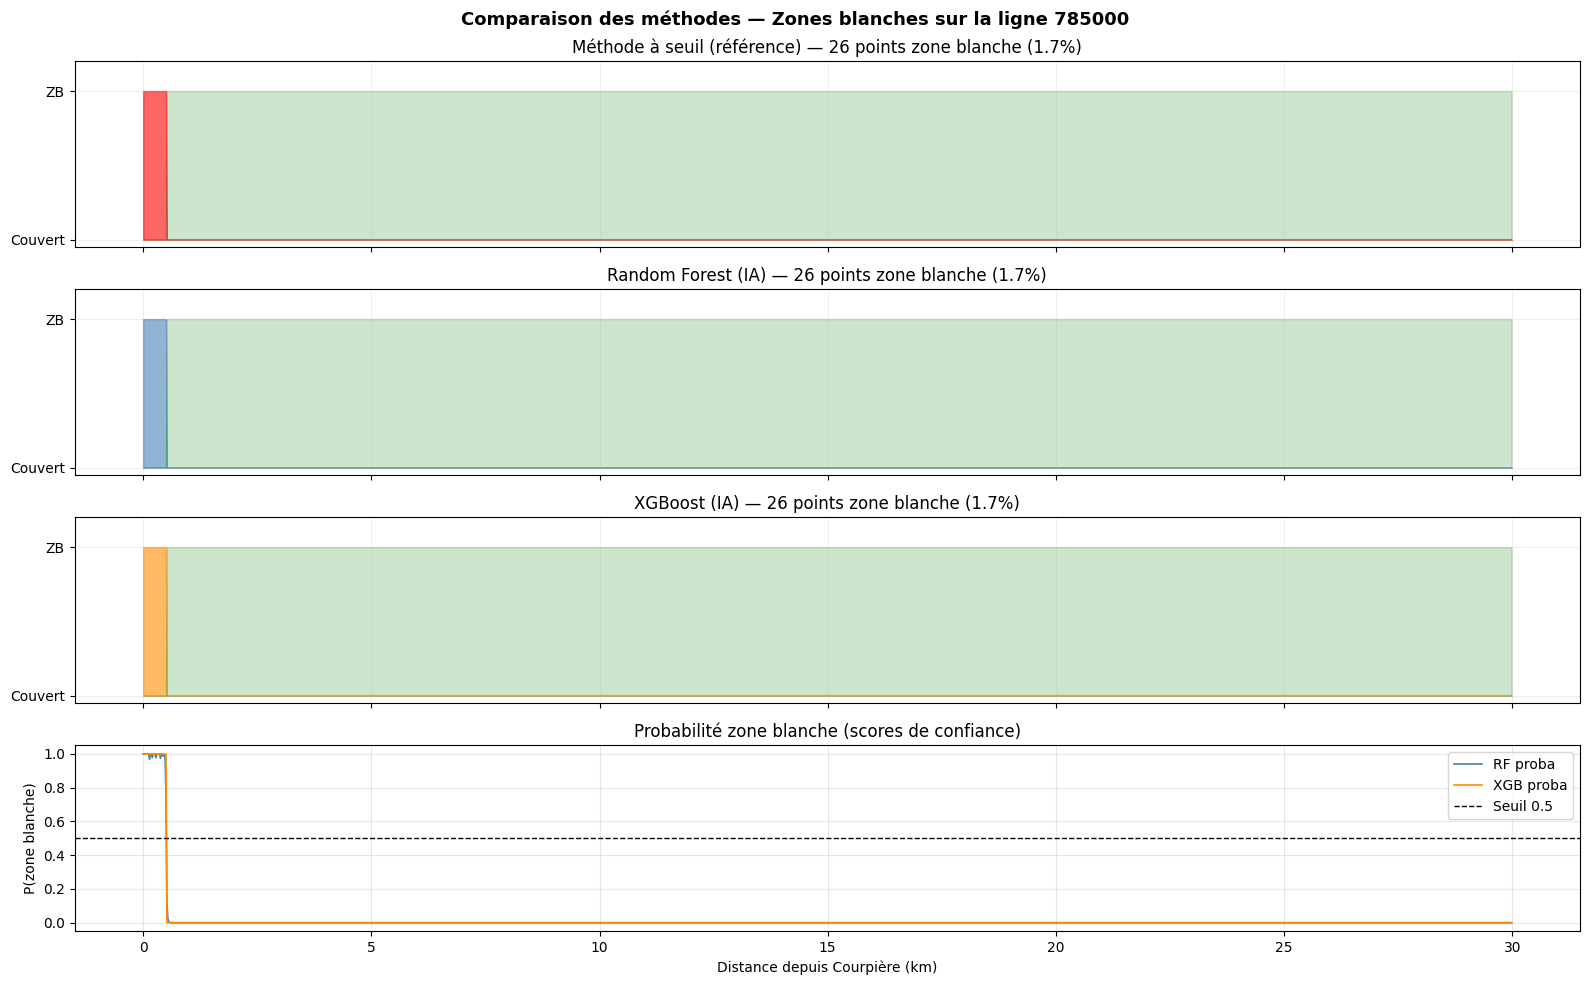

✓ Graphe comparatif sauvegardé


In [24]:
# ── Visualisation comparaison sur la ligne ────────────────────────────────────
by_point['pred_rf']  = y_pred_rf
if XGBOOST_OK:
    by_point['pred_xgb'] = y_pred_xgb
    by_point['proba_xgb'] = y_proba_xgb
by_point['proba_rf'] = y_proba_rf

n_panels = 4 if XGBOOST_OK else 3
fig, axes = plt.subplots(n_panels, 1, figsize=(16, n_panels * 2.5), sharex=True)
fig.suptitle("Comparaison des méthodes — Zones blanches sur la ligne 785000",
             fontsize=13, fontweight='bold')

dist = by_point['distance_km']

def plot_zb_band(ax, mask, label, color, alpha=0.6):
    ax.fill_between(dist, 0, mask.astype(float), alpha=alpha, color=color)
    ax.fill_between(dist, 0, (1-mask).astype(float), alpha=0.2, color='green')
    n_zb = mask.sum()
    ax.set_title(f"{label} — {n_zb} points zone blanche ({n_zb/len(mask)*100:.1f}%)")
    ax.set_ylim(-0.05, 1.2)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Couvert', 'ZB'])
    ax.grid(alpha=0.2)

plot_zb_band(axes[0], by_point['label_seuil'].astype(bool), 'Méthode à seuil (référence)', 'red')
plot_zb_band(axes[1], by_point['pred_rf'].astype(bool), 'Random Forest (IA)', 'steelblue')

if XGBOOST_OK:
    plot_zb_band(axes[2], by_point['pred_xgb'].astype(bool), 'XGBoost (IA)', 'darkorange')
    # Probabilités
    axes[3].plot(dist, by_point['proba_rf'],  color='steelblue',  lw=1.2, label='RF proba')
    axes[3].plot(dist, by_point['proba_xgb'], color='darkorange', lw=1.2, label='XGB proba')
    axes[3].axhline(0.5, color='black', ls='--', lw=1.0, label='Seuil 0.5')
    axes[3].set_title('Probabilité zone blanche (scores de confiance)')
    axes[3].set_ylabel('P(zone blanche)')
    axes[3].legend(loc='upper right')
    axes[3].grid(alpha=0.3)
else:
    axes[2].plot(dist, by_point['proba_rf'], color='steelblue', lw=1.2)
    axes[2].axhline(0.5, color='black', ls='--', lw=1.0)
    axes[2].set_title('RF — Probabilité zone blanche')
    axes[2].grid(alpha=0.3)

axes[-1].set_xlabel('Distance depuis Courpière (km)')
plt.tight_layout()
plt.savefig('comparaison_methodes_ligne.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphe comparatif sauvegardé")

---
## 5. Carte Folium comparative (méthode IA vs seuil)

In [25]:
if FOLIUM_OK:
    m2 = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')

    pred_col = 'pred_xgb' if XGBOOST_OK else 'pred_rf'
    model_name = 'XGBoost' if XGBOOST_OK else 'Random Forest'

    for _, row in by_point.iterrows():
        seuil_zb = row['label_seuil'] == 1
        ia_zb    = row[pred_col] == 1

        if seuil_zb and ia_zb:
            color = 'red'          # Les deux détectent ZB
            icon_color = 'red'
        elif not seuil_zb and not ia_zb:
            color = 'green'        # Les deux détectent couvert
            icon_color = 'green'
        elif seuil_zb and not ia_zb:
            color = 'orange'       # Seuil dit ZB mais IA dit couvert
            icon_color = 'orange'
        else:
            color = 'purple'       # IA dit ZB mais seuil dit couvert
            icon_color = 'purple'

        popup_text = (
            f"<b>Point {int(row['point_id'])}</b><br>"
            f"km : {row['distance_km']:.2f}<br>"
            f"Altitude : {row['altitude_m']:.0f} m<br>"
            f"SNR max : {row['max_snr']:.1f} dB<br>"
            f"Débit max : {row['max_debit']:.1f} Mbps<br>"
            f"RTT min : {row['min_rtt']:.0f} ms<br>"
            f"<b>Seuil : {'ZB' if seuil_zb else 'OK'}</b><br>"
            f"<b>{model_name} : {'ZB' if ia_zb else 'OK'}</b>"
        )

        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=5 if (seuil_zb or ia_zb) else 3,
            color=color, fill=True,
            fill_color=color, fill_opacity=0.8,
            popup=folium.Popup(popup_text, max_width=260)
        ).add_to(m2)

    legend_html = f'''
    <div style="position: fixed; bottom: 30px; left: 30px; z-index:1000;
                background:white; padding:12px; border:2px solid #ccc; border-radius:8px;">
        <b>Comparaison Seuil vs {model_name}</b><br>
        <span style="color:green">●</span> Les deux : Couvert<br>
        <span style="color:red">●</span> Les deux : Zone blanche<br>
        <span style="color:orange">●</span> Seuil=ZB / IA=Couvert<br>
        <span style="color:purple">●</span> IA=ZB / Seuil=Couvert
    </div>
    '''
    m2.get_root().html.add_child(folium.Element(legend_html))
    m2.save('carte_comparaison_ia_seuil.html')
    print("✓ Carte comparative sauvegardée : carte_comparaison_ia_seuil.html")
    display(m2)
else:
    print("Folium non disponible.")

✓ Carte comparative sauvegardée : carte_comparaison_ia_seuil.html


---
## 6. Conclusion et choix

Ce notebook génère 3 livrables pour aider à choisir l'approche :

| Fichier généré | Contenu |
|---|---|
| `zone_blanche_methode_seuil_graphe.png` | Visualisation 2D — méthode à seuil |
| `comparaison_methodes_ligne.png` | Comparaison des 3 méthodes sur la ligne |
| `carte_zone_blanche_seuil.html` | Carte Folium — méthode seuil |
| `carte_comparaison_ia_seuil.html` | Carte Folium — comparaison seuil vs IA |
| `rf_evaluation.png` | Matrice confusion + ROC Random Forest |
| `xgb_evaluation.png` | Matrice confusion + ROC XGBoost |
| `rf_feature_importance.png` | Feature importance Random Forest |
| `xgb_feature_importance.png` | Feature importance XGBoost |

### Critères de choix
- Si **F1 ≈ 1.0** pour les deux modèles IA → les zones blanches = tunnels sont très faciles à détecter depuis les signaux radio. La méthode à seuil est suffisante.
- Si le classifieur IA détecte des zones blanches supplémentaires (hors tunnels) non identifiées par le seuil → l'IA apporte une valeur ajoutée réelle.
- Pour le mémoire : **les deux approches sont défendables**. L'IA est plus robuste si le dataset est étendu à de nouvelles zones.